# Logistic Regression Code Goes Here

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

seed = 1234
np.random.seed(seed)

In [2]:
def make_bow(df):
    text = df['text']
    y_scores = df['label']

    # Add the line break character to the list of stop words.
    sw = list(ENGLISH_STOP_WORDS.union(["br"]))

    # Create a vectorizer that considers bigrams, just to see what happens.
    # I imagine that movie reviewers might use certain phrases to describe
    # their sentiment, and that's important to consider in classification.
    vectorizer = CountVectorizer(stop_words = sw, min_df = 0.0, ngram_range = (1, 2))

    # Note that <fit_transform> returns a sparse matrix.
    X_bow = vectorizer.fit_transform(text)

    # Scale down the training data.
    scaler = MaxAbsScaler()
    X_bow_scaled = scaler.fit_transform(X_bow)

    return X_bow_scaled, y_scores, vectorizer, scaler, text

In [3]:
# Read the training data into a Pandas dataframe.
# Partitioning of data was done prior to reading.
df_tr = pd.read_parquet("../data/train.parquet")

# 
df_tr, df_va = train_test_split(df_tr, test_size = 0.25, shuffle = True)

# Process the training data into a bag of words representation.
X_tr, y_tr, vectorizer, scaler, text = make_bow(df_tr)

# Read and transform the testing data.
X_va = vectorizer.transform(df_va['text'])

# Scale down the testing data.
X_va = scaler.transform(X_va)
y_va = df_va['label']

In [4]:
def most_significant_terms(classifier, vectorizer, K):
    coefficients = classifier.coef_.flatten().tolist()
    words = vectorizer.get_feature_names_out()

    word_list = list(zip(words, coefficients))
    sorted_word_list = sorted(word_list, key = lambda pair: pair[1])
                                                        
    # extract topK positive terms
    topK_neg_terms = [ pair[0] for pair in sorted_word_list[:K] ]
    topK_neg_terms.reverse()

    # extract corresponding weights
    topK_neg_weights = [ pair[1] for pair in sorted_word_list[:K] ]
    topK_neg_weights.reverse()

    # extract topK negative terms
    topK_pos_terms = [ pair[0] for pair in sorted_word_list[-K:] ]
    topK_pos_terms.reverse()

    # extract corresponding weights
    topK_pos_weights = [ pair[1] for pair in sorted_word_list[-K:] ]
    topK_pos_weights.reverse()
    
    print('topK_pos_weights', topK_pos_weights)
    print('topK_pos_terms', topK_pos_terms)
    print('topK_neg_weights', topK_neg_weights)
    print('topK_neg_terms',topK_neg_terms)
    return (topK_pos_weights, topK_neg_weights, topK_pos_terms, topK_neg_terms)

In [5]:
tr_acc_points = []
va_acc_points = []

for P in ['l1', 'l2']:
    classifier = LogisticRegression(penalty = P, solver = 'liblinear', max_iter = 100)
    classifier.fit(X_tr, y_tr)

    tr_y_pred = classifier.predict(X_tr)
    va_y_pred = classifier.predict(X_va)

    tr_acc = classifier.score(X_tr, y_tr) * 100
    va_acc = classifier.score(X_va, y_va) * 100

    tr_acc_points.append(tr_acc)
    va_acc_points.append(va_acc)
    
    print("PREVIEW VALIDATION ACCURACY: ", format(va_acc, '.2f'))

for S in ['lbfgs', 'newton-cg', 'sag']: 
    classifier = LogisticRegression(penalty = 'l2', solver = S, max_iter = 100)
    classifier.fit(X_tr, y_tr)

    tr_y_pred = classifier.predict(X_tr)
    va_y_pred = classifier.predict(X_va)

    tr_acc = classifier.score(X_tr, y_tr) * 100
    va_acc = classifier.score(X_va, y_va) * 100

    tr_acc_points.append(tr_acc)
    va_acc_points.append(va_acc)
    
    print("PREVIEW VALIDATION ACCURACY: ", format(va_acc, '.2f'))

'''
for P in ['l1', 'l2']:
    classifier = LogisticRegression(penalty = P, solver = 'saga', max_iter = 10)
    classifier.fit(X_tr, y_tr)
    
    pred = classifier.predict(X_va)
    acc = classifier.score(X_va, y_va) * 100
    
    print("TESTING ACCURACY: ", format(acc, '.2f'))
'''

PREVIEW VALIDATION ACCURACY:  86.46
PREVIEW VALIDATION ACCURACY:  88.93
PREVIEW VALIDATION ACCURACY:  88.72
PREVIEW VALIDATION ACCURACY:  88.77
PREVIEW VALIDATION ACCURACY:  88.93


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


'\nfor P in [\'l1\', \'l2\']:\n    classifier = LogisticRegression(penalty = P, solver = \'saga\', max_iter = 10)\n    classifier.fit(X_tr, y_tr)\n\n    pred = classifier.predict(X_va)\n    acc = classifier.score(X_va, y_va) * 100\n\n    print("TESTING ACCURACY: ", format(acc, \'.2f\'))\n'

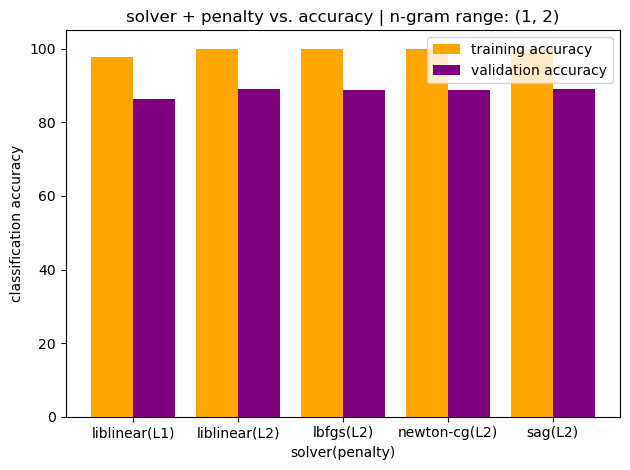

In [6]:
methods = ["liblinear(L1)", "liblinear(L2)", "lbfgs(L2)", "newton-cg(L2)", "sag(L2)"]

w, x = 0.4, np.arange(len(methods))

plt.bar(x - w/2, tr_acc_points, color = 'orange', width = w, label = "training accuracy")
plt.bar(x + w/2, va_acc_points, color = 'purple', width = w, label = "validation accuracy")

plt.xlabel("solver(penalty)")
plt.ylabel("classification accuracy")
plt.title("solver + penalty vs. accuracy | n-gram range: (1, 2)")
plt.xticks([0, 1, 2, 3, 4], methods)
plt.legend()

plt.tight_layout()
plt.show()

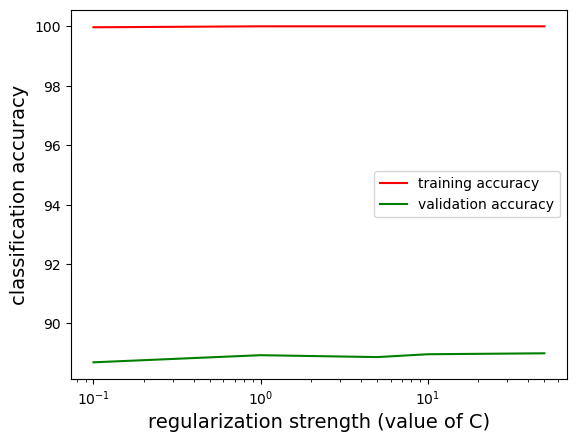

In [7]:
tr_acc_points_per_C = []
va_acc_points_per_C = []

cs = [0.1, 1, 5, 10, 50]

for c in cs:
    classifier = LogisticRegression(penalty = 'l2', solver = 'liblinear', C = c, fit_intercept = True)
    classifier.fit(X_tr, y_tr)
    
    tr_y_pred = classifier.predict(X_tr)
    va_y_pred = classifier.predict(X_va)
    
    tr_acc = classifier.score(X_tr, y_tr) * 100
    va_acc = classifier.score(X_va, y_va) * 100

    tr_acc_points_per_C.append(tr_acc)
    va_acc_points_per_C.append(va_acc)

fig, axes = plt.subplots()
axes.semilogx(cs, tr_acc_points_per_C, color='red', label='training accuracy')
axes.semilogx(cs, va_acc_points_per_C, color='green', label='validation accuracy')
    
axes.set_xlabel('regularization strength (value of C)', fontsize=14)
axes.set_ylabel('classification accuracy', fontsize=14)
    
axes.legend()
    

In [8]:
# Output the top twenty highest/lowest weighted words in the bag of words.
classifier = LogisticRegression(penalty = 'l2', solver = 'liblinear', C = 1.0, fit_intercept = True)
classifier.fit(X_tr, y_tr)
output = most_significant_terms(classifier, vectorizer, K=20)

topK_pos_weights [3.195879153086602, 2.39005034887198, 2.267615418346416, 1.7141372259062433, 1.6092283478000604, 1.4738069856443112, 1.459284503114323, 1.212207997752847, 1.1957003753613409, 1.1942248541917817, 1.1862843766281854, 1.1772684576339176, 1.1556234898539242, 1.1322660425227373, 1.0913637941134136, 1.076203296615109, 1.0696410978378128, 1.0509516548810283, 1.0291513386308242, 1.0269757657240195]
topK_pos_terms ['great', 'wonderful', 'excellent', 'loved', 'enjoyed', 'perfect', 'best', 'today', 'funniest', 'fun', 'beautiful', 'highly', 'entertaining', 'wonderfully', 'makes', 'favorite', 'brilliant', 'love', 'enjoy', 'beautifully']
topK_neg_weights [-1.3068672315688041, -1.3131854599693158, -1.3519455835795229, -1.3682657407502279, -1.3732705472044358, -1.3878594170565888, -1.4560643858277638, -1.490294116059452, -1.5227617816035377, -1.623249054018416, -1.6241889190171783, -1.6354339008792405, -1.6426782725959732, -1.6972771686571517, -1.964160711882202, -2.030383057137166, -

In [9]:
y_va_pred = classifier.predict(X_va)
errors = np.where(y_va_pred != y_va)[0]

# List five of the misclassified reviews.
for i in range(5):
    misclassed = df_va.iloc[errors[i]]
    print(misclassed['text'])
    print("[misclassified as " + ("negative]" if misclassed['label'] else "positive]"))
    print()

Like all the Taviani Brothers films, this one looks great, but it is rotten to the core with false romanticism, and coincidences heap upon each other in some facsimile of a "story". In actuality, this is really just a sentimentally cheap tear jerker posing as an intellectually distinguished art film.
[misclassified as positive]

First of all the movie, is an ingenious work of art(movie). The plot was filled with surprises, a little kid pretends to be a grown up inherits one million dollars and how he spends it. I mean how whacked out is this. Walt Disney really outdid themselves this time. The comedy is most of the times expected but the other times unexpected. I mean was this movie OK or was this movie OK. It also teaches a lot about wise youths and I this kid is really wise and a bit time smart pants. But also it sucks. How the heck could a guy like that kid get a hot police babe and his dad let him go free. That's like let a killer get bailed free for ten years. If I were to do that

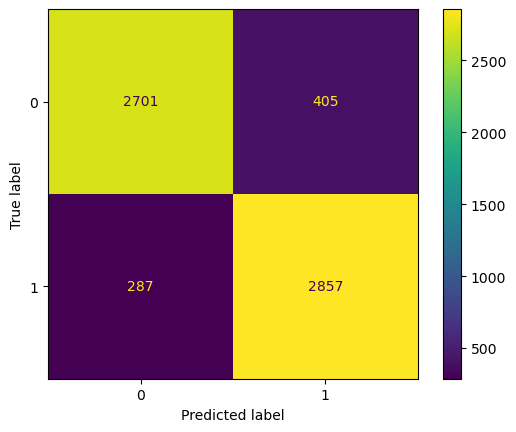

In [10]:
m = confusion_matrix(y_va, y_va_pred)
_ = ConfusionMatrixDisplay(m).from_predictions(y_va, y_va_pred)

In [14]:
df_te = pd.read_parquet("../data/test.parquet")

X_te = vectorizer.transform(df_te['text'])
X_te = scaler.transform(X_te)

y_te = df_te['label']

y_te_pred = classifier.predict(X_te)

print(classification_report(y_te, y_te_pred, target_names = ["-","+"]))

              precision    recall  f1-score   support

           -       0.89      0.87      0.88     12500
           +       0.88      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



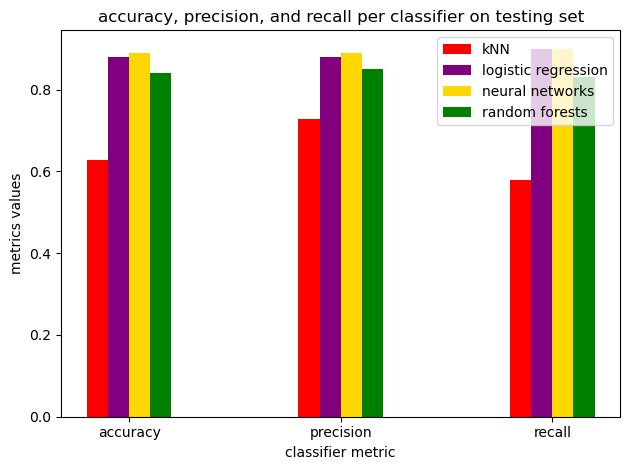

In [45]:
accuracy_scores = [0.628, 0.88, 0.89, 0.84]
precision_scores = [0.729, 0.88, 0.89, 0.85]
recall_scores = [0.58, 0.90, 0.90, 0.83]

kNN_scores = [0.628, 0.729, 0.58]
log_reg_scores = [0.88, 0.88, 0.90]
nn_scores = [0.89, 0.89, 0.90]
rf_scores = [0.84, 0.85, 0.83]

metrics = ['accuracy', 'precision', 'recall']

w, x = 0.4, np.arange(len(metrics))

plt.bar(x - 3 * w/8, kNN_scores, color = 'red', width = w/4, label = "kNN")
plt.bar(x - w/8, log_reg_scores, color = 'purple', width = w/4, label = "logistic regression")
plt.bar(x + w/8, nn_scores, color = 'gold', width = w/4, label = "neural networks")
plt.bar(x + 3 * w/8, rf_scores, color = 'green', width = w/4, label = "random forests")

plt.xlabel("classifier metric")
plt.ylabel("metrics values")
plt.title("accuracy, precision, and recall per classifier on testing set")
plt.xticks([0, 1, 2], metrics)
plt.legend()

plt.tight_layout()
plt.show()